In [58]:
# Test cell to check sensitivity_results
print("Testing sensitivity_results availability...")

try:
    print(f"sensitivity_results exists: {type(sensitivity_results)}")
    print(f"Length: {len(sensitivity_results)}")
    
    if len(sensitivity_results) > 0:
        first = sensitivity_results[0]
        print(f"First result keys: {list(first.keys())}")
        gdf = first['results']
        print(f"Columns: {list(gdf.columns)}")
        print("✅ Data looks good!")
    else:
        print("❌ Empty results")
        
except NameError:
    print("❌ sensitivity_results not found")
except Exception as e:
    print(f"❌ Error: {e}")

Testing sensitivity_results availability...
sensitivity_results exists: <class 'list'>
Length: 216
First result keys: ['flood_threshold', 'repair_threshold', 'damage_ratio_coefficients', 'repair_time_coefficients', 'results', 'timestep_results']
Columns: ['geometry', 'damage_ratio', 'repair_time', 'accessible', 'operational', 'final_hazard_value']
✅ Data looks good!


# Middenspanning Stedin

In [1]:
from pathlib import Path
import geopandas as gpd
import folium 
from shapely.geometry import LineString, Polygon, box
import rasterio
import matplotlib.pyplot as plt
from shapely.geometry import shape

import numpy as np
import geopandas as gpd
from scipy.spatial import Voronoi
from shapely.geometry import Polygon

from shapely.geometry import Point
from rasterio.transform import Affine

import os



In [2]:
# root_dir = Path(r'C:\python\Use_case_stedin')
root_dir = Path.cwd().parent
assert root_dir.exists()
print(f"Root directory: {root_dir}")
electricity_data_path = root_dir / 'data' / 'electricity'
assert electricity_data_path.exists()

Root directory: c:\repos\powerpath


In [3]:
ls_station_path = electricity_data_path.joinpath("ls_stations_clipped.shp")
ls_stations = gpd.read_file(ls_station_path).to_crs("EPSG:28992")  # Ensure CRS matches
ls_stations_centroids = ls_stations['geometry'].representative_point()
bounding_box_ls = ls_stations_centroids.union_all().convex_hull

msls_station_path = electricity_data_path.joinpath("msls_stations_clipped.shp")
msls_stations = gpd.read_file(msls_station_path).to_crs("EPSG:28992")  # Ensure CRS matches
msls_stations_centroids = msls_stations['geometry'].representative_point()
bounding_box_msls = msls_stations_centroids.union_all().convex_hull

ms_station_path = electricity_data_path.joinpath("ms_stations_clipped.shp")
ms_stations = gpd.read_file(ms_station_path).to_crs("EPSG:28992")  # Ensure CRS matches
ms_stations_centroids = ms_stations['geometry'].representative_point()
bounding_box_ms = ms_stations_centroids.union_all().convex_hull

hazard_path = root_dir / 'data' / 'static' / 'hazard' / 'processed' / 'timesteps'

In [4]:
# Functions
def voronoi_polygons(gdf, bounding_box):
    points = gdf.geometry.apply(lambda geom: (geom.x, geom.y)).tolist()
    vor = Voronoi(points)
    polygons = []
    for region in vor.regions:
        if not -1 in region and len(region) > 0:
            polygon = Polygon([vor.vertices[i] for i in region])
            clipped_polygon = polygon.intersection(bounding_box)
            polygons.append(clipped_polygon)
    return gpd.GeoDataFrame(geometry=polygons)

# Function to get the raster value at a point
def get_raster_value(raster, point):
    row, col = raster.index(point.x, point.y)
    if 0 <= row < raster.height and 0 <= col < raster.width:
        value = raster.read(1)[row, col]
    else:
        value = None  # or some default value indicating out of bounds
    return value


# def assign_hazard_to_voronoi(points_with_hazard, voronoi_gdf_msls):
#     # Ensure both GeoDataFrames have the same CRS
#     if points_with_hazard.crs != voronoi_gdf_msls.crs:
#         points_with_hazard = points_with_hazard.to_crs(voronoi_gdf_msls.crs)
    
#     # Perform spatial join to find polygons containing points
#     joined_gdf = gpd.sjoin(voronoi_gdf_msls, points_with_hazard, how="inner", predicate="contains")
    
#     # Group by Voronoi polygon and aggregate hazard values
#     voronoi_with_hazard = joined_gdf.groupby(joined_gdf.index).agg({'hazard_value': 'mean'}).reset_index()
    
#     # Merge the aggregated hazard values back to the original Voronoi GeoDataFrame
#     voronoi_gdf_msls = voronoi_gdf_msls.merge(voronoi_with_hazard, left_index=True, right_on='index', how='left')
    
#     return voronoi_gdf_msls


def assign_hazard_to_voronoi(points_with_hazard, voronoi):
    # Ensure both GeoDataFrames have the same CRS
    if points_with_hazard.crs != voronoi.crs:
        points_with_hazard = points_with_hazard.to_crs(voronoi.crs)
    
    # Drop points with NaN geometry or hazard values
    points_with_hazard = points_with_hazard.dropna(subset=['geometry', 'hazard_value'])
    
    # Perform spatial join to find polygons containing points
    joined_gdf = gpd.sjoin(voronoi, points_with_hazard, how="inner", predicate="contains")
    
    # Group by Voronoi polygon and aggregate hazard values
    voronoi_with_hazard = joined_gdf.groupby(joined_gdf.index).agg({'hazard_value': 'mean'}).reset_index()
    
    # Merge the aggregated hazard values back to the original Voronoi GeoDataFrame
    voronoi = voronoi.merge(voronoi_with_hazard, left_index=True, right_on='index', how='left')
    
    return voronoi

def find_hazard_value_at_points(hazard_map, gdf, timestep=None):
    """    Find hazard values at point geometries in a GeoDataFrame using a raster hazard map.
    
    Parameters:
    hazard_map (str or Path): Path to the raster hazard map file.
    gdf (gpd.GeoDataFrame): GeoDataFrame with point geometries.
    timestep (int, optional): Timestep for hazard value extraction. If None, uses the latest hazard map.
    
    Returns:
    gpd.GeoDataFrame: GeoDataFrame with hazard values added as a new column.
    """
    with rasterio.open(hazard_map) as src:
        gdf = gdf.to_crs(src.crs)  # Ensure CRS matches
        if timestep is None:
            gdf['hazard_value'] = gdf.geometry.apply(lambda geom: get_raster_value(src, geom))
        else:
            hazval_str= f'hazard_value_{timestep:02d}'
            gdf[hazval_str] = gdf.geometry.apply(lambda geom: get_raster_value(src, geom))
    return gdf

In [ ]:
import matplotlib.pyplot as plt
import pandas as pdG SENSITIVITY RESULTS ===")
import numpy as npimport numpy as npprint(f"sensitivity_results variable exists: {'sensitivity_results' in locals()}")import numpy as npimport numpy as np# Recovery functions

def plot_sensitivity_overlay(sensitivity_results, metric='operational'):t_sensitivity_overlay(sensitivity_results, metric='operational'):tivity_overlay(sensitivity_results, metric='operational'):t_sensitivity_overlay(sensitivity_results, metric='operational'):
    """
    Overlay sensitivity results for a chosen metric (e.g., 'operational', 'damage_ratio', 'repair_time').ic.air_time').ic (e.g., 'operational', 'damage_ratio', 'repair_time').
    Shows mean and spread for each parameter set.ws distribution of final values across parameter combinations.nt(f"sensitivity_results type: {type(sensitivity_results)}")ws distribution of final values across parameter combinations.ws distribution of final values across parameter combinations.
    """
    # Collect all time series for the selected metricity_results:_results:ensitivity results available. Please run the sensitivity analysis first.")ensitivity results available. Please run the sensitivity analysis first.")np.array): Array of hazard values
    all_series = []No sensitivity results available.")itivity_results) > 0:No sensitivity results available. Please run the sensitivity analysis first.")No sensitivity results available. Please run the sensitivity analysis first.")(tuple): Linear coefficients (m, n) for damage_ratio = m*hazard + n
    labels = []
    for result in sensitivity_results:())}")
        gdf = result['results']nalysis results...")
        if metric in gdf.columns and 'timestep' in gdf.columns:
            all_series.append(gdf[metric].values) for the selected metric{type(gdf)}") for the selected metric for the selected metricsitivity_results[0]
            labels.append(
                f"Flood: {result['flood_threshold']}, "
                f"Repair: {result['repair_threshold']}, "
                f"DR: {result['damage_ratio_coefficients']}, "accessible']].head())
                f"RT: {result['repair_time_coefficients']}"n enumerate(sensitivity_results):sult in enumerate(sensitivity_results):(f"Results shape: {gdf.shape if hasattr(gdf, 'shape') else 'No shape'}") Access the results GeoDataFrameepair time function based on damage ratios.
            )he results GeoDataFramemns.tolist() if hasattr(gdf, 'columns') else 'No columns'}")lt['results']* DR + c
    if not all_series:
        print(f"No data found for metric '{metric}'.") as e:f = result['results']f = result['results'] a sample of the dataCheck if the metric column exists:
        return    # Check if the metric column existst(f"Other error: {e}")        if hasattr(gdf, 'head'):    if metric not in gdf.columns:ge_ratios (np.array): Array of damage ratios
                    if metric not in gdf.columns:            # Check if the metric column exists            # Check if the metric column exists            print(f"Sample data:")                print(f"Warning: Metric '{metric}' not found in result {i}. Available columns: {gdf.columns.tolist()}")    coefficients (tuple): Polynomial coefficients (a, b, c) for repair_time = a*DR^2 + b*DR + c
ns)
    # Convert to DataFrame for easier averagingvailable columns: {available_cols}").tolist()}") result {i}. Available columns: {gdf.columns.tolist()}")
    df = pd.DataFrame(all_series).T  # shape: (timesteps, runs)the final values per timestepmes
    timesteps = range(df.shape[0])                                        all_series = []            # Since the GeoDataFrame contains all assets, we need to check if it has timestep-based data    """
al average value for this parameter combinationnsitivity_results, metric='operational'):al average value for this parameter combinational average value for this parameter combination
    plt.figure(figsize=(12, 6))': + c
    # Plot all runs with transparencyf[metric].mean() * 100  # Convert to percentagefor a chosen metric (e.g., 'operational', 'damage_ratio', 'repair_time').f[metric].mean() * 100  # Convert to percentagef[metric].mean() * 100  # Convert to percentageensitivity_results):gdf.groupby('timestep')[metric].mean()
    for i in range(df.shape[1]):
        plt.plot(timesteps, df.iloc[:, i], alpha=0.2, color='gray')alue = gdf[metric].mean()c].mean()alue = gdf[metric].mean()e results GeoDataFrame
    # Plot mean and std===")DataFrame - just the final values given repair time using quadratic formula.
    mean = df.mean(axis=1)d(final_value){type(sensitivity_results)}")d(final_value)d(final_value)tric].mean()R + (c - repair_time) = 0
    std = df.std(axis=1)o length'}")
    plt.plot(timesteps, mean, color='blue', label='Mean')
    plt.fill_between(timesteps, mean - std, mean + std, color='blue', alpha=0.2, label='±1 std')            param_info.append({    if not sensitivity_results:            label = f"FT:{result['flood_threshold']:.1f}_RT:{result['repair_threshold']:.1f}"            label = f"FT:{result['flood_threshold']:.1f}_RT:{result['repair_threshold']:.1f}"                print(f"Warning: Metric '{metric}' not found in result {i}. Available columns: {gdf.columns.tolist()}")                repair_time (float): Current repair time
 result['flood_threshold'],esults!") c)
    plt.xlabel('Timestep (hours)')ir_threshold'],
    plt.ylabel(metric.replace('_', ' ').title())
    plt.title(f"Sensitivity Analysis Overlay: {metric.replace('_', ' ').title()}")'repair_time_coeff': str(result['repair_time_coefficients']),nal values for the selected metricm_info.append({m_info.append({en(gdf) > 0:d damage ratio (positive root)
    plt.legend()alue': final_valued_threshold': result['flood_threshold'],lood_threshold': result['flood_threshold'],nal_value = gdf[metric].mean()eption as e:
    plt.grid(True)': result['repair_threshold'],r_threshold': result['repair_threshold'],f"Result {i}: Final {metric} value = {final_value:.4f}")ror processing result {i}: {e}")ents
    plt.tight_layout()inal_value  'value': final_value  # Create a dummy time series with just the final value repeatedntinueDR^2 + b*DR + (c - repair_time) = 0
    plt.show()        except Exception as e:    for i, result in enumerate(sensitivity_results[:5]):  # Check first 5 only for debugging            })            })                all_series.append([final_value] * 169)  # Assuming 169 timesteps        discriminant = b**2 - 4*a*(c - repair_time)
lt {i}: {e}")
# Simple test first
print("Starting sensitivity analysis plotting...")                print(f"  Result type: {type(result)}")            print(f"Error processing result {i}: {e}")            print(f"Error processing result {i}: {e}")                f"FT:{result['flood_threshold']:.1f}, RT:{result['repair_threshold']:.1f}"        return        root2 = (-b - np.sqrt(discriminant)) / (2*a)


















































































plot_sensitivity_overlay(sensitivity_results, metric='operational')# Example: overlay for operational statusprint("✅ Plotting completed successfully!")plt.show()plt.tight_layout()plt.suptitle('Sensitivity Analysis: Operational Status', fontsize=16, fontweight='bold')plt.title('Summary Statistics')plt.axis('off')plt.text(0.1, 0.3, f"Range: {max(operational_values) - min(operational_values):.2f}%", transform=plt.gca().transAxes, fontsize=12)plt.text(0.1, 0.4, f"Max: {max(operational_values):.2f}%", transform=plt.gca().transAxes, fontsize=12)plt.text(0.1, 0.5, f"Min: {min(operational_values):.2f}%", transform=plt.gca().transAxes, fontsize=12)plt.text(0.1, 0.6, f"Std Dev: {np.std(operational_values):.2f}%", transform=plt.gca().transAxes, fontsize=12)plt.text(0.1, 0.7, f"Mean: {np.mean(operational_values):.2f}%", transform=plt.gca().transAxes, fontsize=12)plt.text(0.1, 0.8, f"Total Runs: {len(operational_values)}", transform=plt.gca().transAxes, fontsize=12)plt.subplot(2, 2, 4)# Plot 4: Summary statisticsplt.grid(True, alpha=0.3)plt.colorbar(scatter, label='Flood Threshold')plt.title('Operational Status vs Repair Threshold')plt.ylabel('Final Operational Assets (%)')plt.xlabel('Repair Threshold')scatter = plt.scatter(repair_thresholds, operational_scatter, c=colors, alpha=0.6, s=30)    colors.append(result['flood_threshold'])    operational_scatter.append(gdf['operational'].mean() * 100)    gdf = result['results']    repair_thresholds.append(result['repair_threshold'])for result in sensitivity_results:colors = []operational_scatter = []repair_thresholds = []plt.subplot(2, 2, 3)# Plot 3: Scatter plotplt.grid(True, alpha=0.3)plt.title('Effect of Flood Threshold')plt.ylabel('Final Operational Assets (%)')plt.xlabel('Flood Threshold')plt.boxplot(groups, labels=flood_thresholds)    groups.append(group_values)            group_values.append(op_value)            op_value = gdf['operational'].mean() * 100            gdf = result['results']        if result['flood_threshold'] == ft:    for result in sensitivity_results:    group_values = []for ft in flood_thresholds:groups = []flood_thresholds = [0.2, 0.3, 0.4, 0.5]plt.subplot(2, 2, 2)# Plot 2: Box plot by flood thresholdplt.grid(True, alpha=0.3)plt.title('Distribution of Final Operational Status')plt.ylabel('Frequency')plt.xlabel('Final Operational Assets (%)')plt.hist(operational_values, bins=20, alpha=0.7, color='skyblue', edgecolor='black')plt.subplot(2, 2, 1)# Plot 1: Histogramplt.figure(figsize=(12, 8))# Simple plotprint(f"Range: {min(operational_values):.1f}% to {max(operational_values):.1f}%")print(f"Total values extracted: {len(operational_values)}")        print(f"Result {i}: {op_value:.1f}% operational")    if i < 5:  # Print first 5 for verification    operational_values.append(op_value)    op_value = gdf['operational'].mean() * 100  # Convert to percentage    gdf = result['results']for i, result in enumerate(sensitivity_results):operational_values = []# Extract operational values from all resultsprint(f"sensitivity_results available: {len(sensitivity_results)} results")









































































































plot_sensitivity_overlay(sensitivity_results, metric='damage_ratio')print("=== DAMAGE RATIO ANALYSIS ===")print("\n" + "="*60)plot_sensitivity_overlay(sensitivity_results, metric='operational')print("=== OPERATIONAL STATUS ANALYSIS ===")# Run the plotting function for different metrics            print(f"  {param} = {row[param]}: mean = {row['mean']:.4f}, std = {row['std']:.4f}")        for _, row in grouped.iterrows():        print(f"\nEffect of {param}:")        grouped = param_df.groupby(param)['value'].agg(['mean', 'std']).reset_index()    for param in ['flood_threshold', 'repair_threshold']:    print(f"\n=== PARAMETER SENSITIVITY ===")    # Analyze parameter sensitivity        print(f"  Repair time coeff: {max_result['repair_time_coefficients']}")    print(f"  Damage ratio coeff: {max_result['damage_ratio_coefficients']}")    print(f"  Repair threshold: {max_result['repair_threshold']}")    print(f"  Flood threshold: {max_result['flood_threshold']}")    max_result = sensitivity_results[max_idx]    print(f"\nHighest {metric} ({max(values):.4f}):")        print(f"  Repair time coeff: {min_result['repair_time_coefficients']}")    print(f"  Damage ratio coeff: {min_result['damage_ratio_coefficients']}")    print(f"  Repair threshold: {min_result['repair_threshold']}")    print(f"  Flood threshold: {min_result['flood_threshold']}")    min_result = sensitivity_results[min_idx]    print(f"Lowest {metric} ({min(values):.4f}):")    print(f"\n=== EXTREME VALUES ===")        max_idx = values.index(max(values))    min_idx = values.index(min(values))    # Find parameter combinations that give extreme values        print(f"Coefficient of variation: {(std_val/mean_val)*100:.2f}%")    print(f"Range: {min(values):.4f} to {max(values):.4f}")    print(f"Standard deviation: {std_val:.4f}")    print(f"Mean: {mean_val:.4f}")    print(f"Number of sensitivity runs: {len(values)}")    print(f"\n=== SUMMARY STATISTICS for {metric} ===")    # Print summary statistics        plt.show()    plt.tight_layout()        ax4.grid(True, alpha=0.3)    ax4.set_title('Distribution by Repair Threshold')    ax4.set_ylabel(f'Final {metric.replace("_", " ").title()}' + (' (%)' if metric == 'operational' else ''))    ax4.set_xlabel('Repair Threshold')    ax4.boxplot(repair_groups, labels=[f'{rt}' for rt in repair_thresholds_unique])    repair_groups = [param_df[param_df['repair_threshold'] == rt]['value'].values for rt in repair_thresholds_unique]    repair_thresholds_unique = sorted(param_df['repair_threshold'].unique())    # Plot 4: Box plot by repair threshold          ax3.grid(True, alpha=0.3)    ax3.set_title('Distribution by Flood Threshold')    ax3.set_ylabel(f'Final {metric.replace("_", " ").title()}' + (' (%)' if metric == 'operational' else ''))    ax3.set_xlabel('Flood Threshold')    ax3.boxplot(flood_groups, labels=[f'{ft}' for ft in flood_thresholds_unique])    flood_groups = [param_df[param_df['flood_threshold'] == ft]['value'].values for ft in flood_thresholds_unique]    # Plot 3: Box plot by flood threshold        ax2.grid(True, alpha=0.3)    ax2.legend()    ax2.set_title('Effect of Repair Threshold by Flood Threshold')    ax2.set_ylabel(f'Final {metric.replace("_", " ").title()}' + (' (%)' if metric == 'operational' else ''))    ax2.set_xlabel('Repair Threshold')                       alpha=0.7, color=colors[i], label=f'FT: {ft}', s=30)        ax2.scatter(subset['repair_threshold'], subset['value'],         subset = param_df[param_df['flood_threshold'] == ft]    for i, ft in enumerate(flood_thresholds_unique):        colors = plt.cm.viridis(np.linspace(0, 1, len(flood_thresholds_unique)))    flood_thresholds_unique = sorted(param_df['flood_threshold'].unique())    # Plot 2: Flood threshold vs values        param_df = pd.DataFrame(param_info)    # Convert to DataFrame for easier plotting        ax1.legend()    ax1.axvline(mean_val - std_val, color='orange', linestyle=':', alpha=0.7)    ax1.axvline(mean_val + std_val, color='orange', linestyle=':', alpha=0.7, label=f'±1σ: {std_val:.2f}')    ax1.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')    std_val = np.std(values)    mean_val = np.mean(values)    # Add statistics        ax1.grid(True, alpha=0.3)    ax1.set_title('Distribution of Final Values')    ax1.set_ylabel('Frequency')    ax1.set_xlabel(f'Final {metric.replace("_", " ").title()}' + (' (%)' if metric == 'operational' else ''))    ax1.hist(values, bins=20, alpha=0.7, color='skyblue', edgecolor='black')    # Plot 1: Distribution of values        fig.suptitle(f'Sensitivity Analysis: {metric.replace("_", " ").title()}', fontsize=16, fontweight='bold')    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))    # Create comprehensive visualization        print(f"Successfully processed {len(values)} sensitivity runs")            return        print(f"No valid data found for metric '{metric}'.")    if not values:

























































    print(f"Error in plotting: {e}")except Exception as e:    print("sensitivity_results not found - please run the sensitivity analysis first")except NameError:    plot_sensitivity_overlay(sensitivity_results, metric='operational')try:# Try to plot    print(f"Range: {min(values):.2f} to {max(values):.2f}")    print(f"Std: {np.std(values):.2f}")    print(f"Mean: {np.mean(values):.2f}")        plt.show()    plt.grid(True, alpha=0.3)    plt.title(f'Distribution of Final {metric.replace("_", " ").title()} Values')    plt.ylabel('Frequency')    plt.xlabel(f'Final {metric.replace("_", " ").title()}' + (' (%)' if metric == 'operational' else ''))    plt.hist(values, bins=10, alpha=0.7, color='skyblue', edgecolor='black')    plt.figure(figsize=(10, 6))    # Simple plot            return        print("No valid values found!")    if len(values) == 0:    print(f"\nSuccessfully processed {len(values)} values")                continue            print(f"  Error processing result {i}: {e}")        except Exception as e:                        })                'value': final_value                'repair_threshold': result['repair_threshold'],                'flood_threshold': result['flood_threshold'],            param_info.append({            # Store parameter info for analysis                        values.append(final_value)            print(f"  Final {metric} value: {final_value}")                            final_value = gdf[metric].mean()            else:                final_value = gdf[metric].mean() * 100  # Convert to percentage            if metric == 'operational':            # Calculate the final average value for this parameter combination                            continue                print(f"  WARNING: Metric '{metric}' not found. Available: {list(gdf.columns)}")            if metric not in gdf.columns:            # Check if the metric column exists                        print(f"  GDF columns: {list(gdf.columns) if hasattr(gdf, 'columns') else 'No columns'}")            print(f"  GDF type: {type(gdf)}")            gdf = result['results']            # Access the results GeoDataFrame                        print(f"  Result keys: {list(result.keys()) if hasattr(result, 'keys') else 'No keys'}")











































































































    print("sensitivity_results not found or empty. Please run the sensitivity analysis first.")else:    plot_sensitivity_overlay(sensitivity_results, metric='damage_ratio')    print("Plotting damage ratio sensitivity analysis...")    print("\n" + "="*50)        plot_sensitivity_overlay(sensitivity_results, metric='operational')    print("\nPlotting operational status sensitivity analysis...")if 'sensitivity_results' in locals() and sensitivity_results:# Check if sensitivity_results exists and plotprint(f"\nsimulate_asset_damage_recovery function exists: {'simulate_asset_damage_recovery' in locals()}")# Let's also check what the simulate_asset_damage_recovery function returnsprint(f"results exists: {'results' in locals()}")print(f"\ngdf_msls_timesteps exists: {'gdf_msls_timesteps' in locals()}")# Also check if the main simulation results exist            print(f"First GDF shape: {gdf.shape if hasattr(gdf, 'shape') else 'No shape'}")            print(f"First GDF columns: {gdf.columns.tolist() if hasattr(gdf, 'columns') else 'No columns'}")            print(f"First GDF type: {type(gdf)}")            gdf = sensitivity_results[0]['results']        if hasattr(sensitivity_results[0], 'keys') and 'results' in sensitivity_results[0]:                print(f"First result keys: {sensitivity_results[0].keys() if hasattr(sensitivity_results[0], 'keys') else 'No keys'}")        print(f"First result type: {type(sensitivity_results[0])}")    if hasattr(sensitivity_results, '__len__') and len(sensitivity_results) > 0:        print(f"sensitivity_results length: {len(sensitivity_results) if hasattr(sensitivity_results, '__len__') else 'No length'}")    print(f"sensitivity_results type: {type(sensitivity_results)}")if 'sensitivity_results' in locals():print(f"sensitivity_results exists: {'sensitivity_results' in locals()}")print("Checking available variables...")# First, let's check what variables we actually have    print(f"  Repair time coeff: {max_result['repair_time_coefficients']}")    print(f"  Damage ratio coeff: {max_result['damage_ratio_coefficients']}")    print(f"  Repair threshold: {max_result['repair_threshold']}")    print(f"  Flood threshold: {max_result['flood_threshold']}")    max_result = sensitivity_results[max_idx]    print(f"\nHighest {metric} ({max(values):.4f}):")        print(f"  Repair time coeff: {min_result['repair_time_coefficients']}")    print(f"  Damage ratio coeff: {min_result['damage_ratio_coefficients']}")    print(f"  Repair threshold: {min_result['repair_threshold']}")    print(f"  Flood threshold: {min_result['flood_threshold']}")    min_result = sensitivity_results[min_idx]    print(f"\nLowest {metric} ({min(values):.4f}):")        max_idx = values.index(max(values))    min_idx = values.index(min(values))    # Find parameter combinations that give extreme values        print(f"Range: {min(values):.4f} to {max(values):.4f}")    print(f"Standard deviation: {std_val:.4f}")    print(f"Mean: {mean_val:.4f}")    print(f"Number of sensitivity runs: {len(values)}")    print(f"\nSummary for {metric}:")    # Print summary statistics        plt.show()    plt.tight_layout()        ax2.grid(True, alpha=0.3)    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')    ax2.set_title(f'{metric.replace("_", " ").title()} vs. Repair Threshold')    ax2.set_ylabel(f'Final {metric.replace("_", " ").title()}' + (' (%)' if metric == 'operational' else ''))    ax2.set_xlabel('Repair Threshold')                       alpha=0.7, color=colors[i], label=f'Flood Threshold: {ft}', s=50)        ax2.scatter(subset['repair_threshold'], subset['value'],         subset = param_df[param_df['flood_threshold'] == ft]    for i, ft in enumerate(flood_thresholds_unique):        colors = plt.cm.viridis(np.linspace(0, 1, len(flood_thresholds_unique)))    flood_thresholds_unique = sorted(param_df['flood_threshold'].unique())    # Group by flood threshold and plot        param_df = pd.DataFrame(param_info)    # Plot 2: Parameter sensitivity (flood threshold vs values)        ax1.legend()    ax1.axvline(mean_val - std_val, color='orange', linestyle=':', alpha=0.7)    ax1.axvline(mean_val + std_val, color='orange', linestyle=':', alpha=0.7, label=f'±1σ: {std_val:.2f}')    ax1.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')    std_val = np.std(values)    mean_val = np.mean(values)    # Add statistics        ax1.grid(True, alpha=0.3)    ax1.set_title(f'Distribution of Final {metric.replace("_", " ").title()} Values')    ax1.set_ylabel('Frequency')    ax1.set_xlabel(f'Final {metric.replace("_", " ").title()}' + (' (%)' if metric == 'operational' else ''))    ax1.hist(values, bins=20, alpha=0.7, color='skyblue', edgecolor='black')    # Plot 1: Distribution of values        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))    # Create visualization        print(f"Successfully processed {len(values)} sensitivity runs")            return        print(f"No valid data found for metric '{metric}'. Check your sensitivity results.")    if not values:                continue


















































































    print("sensitivity_results not found. Please run the sensitivity analysis first.")else:    plot_sensitivity_overlay(sensitivity_results, metric='damage_ratio')    print("Plotting damage ratio sensitivity analysis...")    print("\n" + "="*50)        plot_sensitivity_overlay(sensitivity_results, metric='operational')    print("Plotting operational status sensitivity analysis...")if 'sensitivity_results' in locals() and sensitivity_results:# Check if sensitivity_results exists and plot    print(f"  Repair time coeff: {max_result['repair_time_coefficients']}")    print(f"  Damage ratio coeff: {max_result['damage_ratio_coefficients']}")    print(f"  Repair threshold: {max_result['repair_threshold']}")    print(f"  Flood threshold: {max_result['flood_threshold']}")    max_result = sensitivity_results[max_idx]    print(f"\nHighest {metric} ({max(values):.4f}):")        print(f"  Repair time coeff: {min_result['repair_time_coefficients']}")    print(f"  Damage ratio coeff: {min_result['damage_ratio_coefficients']}")    print(f"  Repair threshold: {min_result['repair_threshold']}")    print(f"  Flood threshold: {min_result['flood_threshold']}")    min_result = sensitivity_results[min_idx]    print(f"\nLowest {metric} ({min(values):.4f}):")        max_idx = values.index(max(values))    min_idx = values.index(min(values))    # Find parameter combinations that give extreme values        print(f"Range: {min(values):.4f} to {max(values):.4f}")    print(f"Standard deviation: {std_val:.4f}")    print(f"Mean: {mean_val:.4f}")    print(f"Number of sensitivity runs: {len(values)}")    print(f"\nSummary for {metric}:")    # Print summary statistics        plt.show()    plt.tight_layout()        ax2.grid(True, alpha=0.3)    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')    ax2.set_title(f'{metric.replace("_", " ").title()} vs. Repair Threshold')    ax2.set_ylabel(f'Final {metric.replace("_", " ").title()}' + (' (%)' if metric == 'operational' else ''))    ax2.set_xlabel('Repair Threshold')                       alpha=0.7, color=colors[i], label=f'Flood Threshold: {ft}', s=50)        ax2.scatter(subset['repair_threshold'], subset['value'],         subset = param_df[param_df['flood_threshold'] == ft]    for i, ft in enumerate(flood_thresholds_unique):        colors = plt.cm.viridis(np.linspace(0, 1, len(flood_thresholds_unique)))    flood_thresholds_unique = sorted(param_df['flood_threshold'].unique())    # Group by flood threshold and plot        param_df = pd.DataFrame(param_info)    # Plot 2: Parameter sensitivity (flood threshold vs values)        ax1.legend()    ax1.axvline(mean_val - std_val, color='orange', linestyle=':', alpha=0.7)    ax1.axvline(mean_val + std_val, color='orange', linestyle=':', alpha=0.7, label=f'±1σ: {std_val:.2f}')    ax1.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')    std_val = np.std(values)    mean_val = np.mean(values)    # Add statistics        ax1.grid(True, alpha=0.3)    ax1.set_title(f'Distribution of Final {metric.replace("_", " ").title()} Values')    ax1.set_ylabel('Frequency')    ax1.set_xlabel(f'Final {metric.replace("_", " ").title()}' + (' (%)' if metric == 'operational' else ''))    ax1.hist(values, bins=20, alpha=0.7, color='skyblue', edgecolor='black')    # Plot 1: Distribution of values        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))    # Create visualization        print(f"Successfully processed {len(values)} sensitivity runs")            return        print(f"No valid data found for metric '{metric}'. Check your sensitivity results.")    if not values:                continue
















































    print("sensitivity_results not found. Please run the sensitivity analysis first.")else:    plot_sensitivity_overlay(sensitivity_results, metric='operational')    print("Plotting operational status overlay...")if 'sensitivity_results' in locals() and sensitivity_results:# Check if sensitivity_results exists and plot    print(f"Range of final values: {df.iloc[-1].min():.4f} to {df.iloc[-1].max():.4f}")    print(f"Mean final value: {mean.iloc[-1]:.4f} ± {std.iloc[-1]:.4f}")    print(f"Number of sensitivity runs: {df.shape[1]}")    print(f"\nSummary for {metric}:")    # Print some summary statistics        plt.show()    plt.tight_layout()    plt.grid(True, alpha=0.3)    plt.legend()    plt.title(f"Sensitivity Analysis Overlay: {metric.replace('_', ' ').title()}")    plt.ylabel(metric.replace('_', ' ').title())    plt.xlabel('Timestep (hours)')    plt.fill_between(timesteps, mean - std, mean + std, color='blue', alpha=0.2, label='±1 std')    plt.plot(timesteps, mean, color='blue', linewidth=2, label=f'Mean (n={df.shape[1]})')    std = df.std(axis=1)    mean = df.mean(axis=1)    # Plot mean and std            plt.plot(timesteps, df.iloc[:, i], alpha=0.3, color='gray', linewidth=0.5)    for i in range(df.shape[1]):    # Plot all runs with transparency        plt.figure(figsize=(12, 8))    timesteps = range(df.shape[0])    df = pd.DataFrame(all_series).T  # shape: (timesteps, runs)    # Convert to DataFrame for easier averaging        print(f"Successfully processed {len(all_series)} sensitivity runs")            return        print(f"No valid data found for metric '{metric}'. Check your sensitivity results.")    if not all_series:                continue            print(f"Error processing result {i}: {e}")        except Exception as e:                        )









































    print("sensitivity_results not found. Please run the sensitivity analysis first.")else:    plot_sensitivity_overlay(sensitivity_results, metric='operational')    print("Plotting operational status overlay...")if 'sensitivity_results' in locals() and sensitivity_results:# Check if sensitivity_results exists and plot    print(f"Range of final values: {df.iloc[-1].min():.4f} to {df.iloc[-1].max():.4f}")    print(f"Mean final value: {mean.iloc[-1]:.4f} ± {std.iloc[-1]:.4f}")    print(f"Number of sensitivity runs: {df.shape[1]}")    print(f"\nSummary for {metric}:")    # Print some summary statistics        plt.show()    plt.tight_layout()    plt.grid(True, alpha=0.3)    plt.legend()    plt.title(f"Sensitivity Analysis Overlay: {metric.replace('_', ' ').title()}")    plt.ylabel(metric.replace('_', ' ').title())    plt.xlabel('Timestep (hours)')    plt.fill_between(timesteps, mean - std, mean + std, color='blue', alpha=0.2, label='±1 std')    plt.plot(timesteps, mean, color='blue', linewidth=2, label=f'Mean (n={df.shape[1]})')    std = df.std(axis=1)    mean = df.mean(axis=1)    # Plot mean and std            plt.plot(timesteps, df.iloc[:, i], alpha=0.3, color='gray', linewidth=0.5)    for i in range(df.shape[1]):    # Plot all runs with transparency        plt.figure(figsize=(12, 8))    timesteps = range(df.shape[0])    df = pd.DataFrame(all_series).T  # shape: (timesteps, runs)    # Convert to DataFrame for easier averaging        all_series = [series[:min_length] for series in all_series]    min_length = min(len(series) for series in all_series)    # Ensure all series have the same length            # Return the positive root
        positive_roots = [r for r in [root1, root2] if r >= 0]
        return max(positive_roots) if positive_roots else 0.0
    else:
        return 0.0

def simulate_asset_damage_recovery(
    gdf_assets, 
    hazard_path, 
    timesteps=None,
    damage_ratio_func=default_damage_ratio_function,
    repair_time_func=default_repair_time_function,
    damage_ratio_coefficients=(0.0468, 0.0077), #(FEMA, 2009; Sánchez-Muñoz et al., 2020) USA
    repair_time_coefficients=(702.72, 3.14, 1.9891), #(Sánchez-Muñoz et al., 2020) Bristol(UK)/Barcelona(SP)
    flood_threshold=0.2, # Ref?
    repair_threshold=2.0, # Repair time threshold for recovery calculation, set to 2 hours (1.9891) as lower limit of the repair time curve
    record_results=True,
    verbose=True
):
    """
    Simulate asset damage and recovery over timesteps using NumPy arrays for optimization.
    
    Parameters:
    gdf_assets (gpd.GeoDataFrame): GeoDataFrame with asset geometries
    hazard_path (Path): Path to hazard map files
    timesteps (np.array): Array of timestep values (default: 0 to 7*24+1)
    damage_ratio_func (callable): Function to calculate damage ratio from hazard values
    repair_time_func (callable): Function to calculate repair time from damage ratios
    damage_ratio_coefficients (tuple): Coefficients for damage ratio function (m, n)
    repair_time_coefficients (tuple): Coefficients for repair time polynomial (a, b, c)
    flood_threshold (float): Hazard value threshold for flooding (default: 0.2)
    repair_threshold (float): Repair time threshold for recovery calculation (default: 2.0)
    record_results (bool): Whether to record timestep results (default: True)
    verbose (bool): Whether to print progress messages (default: True)
    
    Returns:
    tuple: (final_gdf, results_dict) - Final asset states and recorded results
    """
    
    if timesteps is None:
        timesteps = np.arange(0, 7*24+1, 1)

    # Convert to NumPy arrays for optimized operations
    n_assets = len(gdf_assets)

    # Initialize NumPy arrays for asset states
    damage_ratio = np.zeros(n_assets, dtype=np.float64)
    repair_time = np.zeros(n_assets, dtype=np.float64)
    accessible = np.ones(n_assets, dtype=bool)
    operational = np.ones(n_assets, dtype=bool)
    current_hazard_values = np.zeros(n_assets, dtype=np.float64)

    # Create temporary GeoDataFrame for hazard value extraction
    temp_gdf = gdf_assets.copy()

    # Results recording
    recorded_variables = ['asset_id', 'timestep', 'day', 'damage_ratio', 'repair_time', 'accessible', 'operational', 'hazard_value']
    results = {var: [] for var in recorded_variables} if record_results else None

    # Iterate over each timestep
    for timestep in timesteps:
        day_counter = timestep // 24
        day_counter_str = str(day_counter).zfill(2)

        # Every 24 hour-timesteps, process the hazard map for that day
        if timestep % 24 == 0:
            # Load hazard map for this day
            hazard_map = hazard_path / f'clipped_hazard_map_{day_counter:02d}.tif'
            if not hazard_map.exists():
                if verbose:
                    print(f"Warning: Hazard map for day {day_counter} does not exist at {hazard_map}")
                current_hazard_values.fill(0.0)
            else:
                if verbose:
                    print(f"Processing timestep {timestep} (day {day_counter})")
                # Extract hazard values using the existing function
                temp_gdf = find_hazard_value_at_points(hazard_map, temp_gdf, day_counter)
                haz_val_str = f'hazard_value_{day_counter_str}'
                current_hazard_values = temp_gdf[haz_val_str].fillna(0.0).values

            # Vectorized operations using NumPy arrays
            flooded_mask = current_hazard_values > flood_threshold
            operational[flooded_mask] = False

            # For assets under repair, solve for current damage ratio
            repair_mask = repair_time > repair_threshold
            if np.any(repair_mask):
                repair_indices = np.where(repair_mask)[0]
                for idx in repair_indices:
                    damage_ratio[idx] = solve_damage_ratio_from_repair_time(
                        repair_time[idx], repair_time_coefficients
                    )

            # Update damage ratio for flooded assets (cumulative damage)
            if np.any(flooded_mask):
                dr_new = damage_ratio_func(current_hazard_values[flooded_mask], damage_ratio_coefficients)
                damage_ratio[flooded_mask] = np.maximum(damage_ratio[flooded_mask], dr_new)

            # Only recalculate repair time for assets with damage > 0
            damaged_mask = damage_ratio > 0
            if np.any(damaged_mask):
                repair_time[damaged_mask] = repair_time_func(
                    damage_ratio[damaged_mask], repair_time_coefficients
                )

        # For each timestep, decrement repair_time if accessible and not flooded [TODO]: add if available repair crews/resources 
        can_repair_mask = accessible & (current_hazard_values <= 0.0)
        repair_time[can_repair_mask] = np.maximum(repair_time[can_repair_mask] - 1, 0)
        
        # Check for completed repairs
        newly_operational = (repair_time == 0) & (~operational)
        if np.any(newly_operational):
            operational[newly_operational] = True
            damage_ratio[newly_operational] = 0.0
            if verbose:
                newly_operational_indices = np.where(newly_operational)[0]
                for idx in newly_operational_indices:
                    print(f"Asset {idx} is operational at timestep {timestep}")

        # Record results for each asset at this timestep
        if record_results:
            n_records = len(damage_ratio)
            results['asset_id'].extend(range(n_records))
            results['timestep'].extend([timestep] * n_records)
            results['day'].extend([day_counter] * n_records)
            results['damage_ratio'].extend(damage_ratio.tolist())
            results['repair_time'].extend(repair_time.tolist())
            results['accessible'].extend(accessible.tolist())
            results['operational'].extend(operational.tolist())
            results['hazard_value'].extend(current_hazard_values.tolist())

    if verbose:
        print("Processing complete")

    # Convert final results back to GeoDataFrame for compatibility
    final_gdf = gdf_assets.copy()
    final_gdf['damage_ratio'] = damage_ratio
    final_gdf['repair_time'] = repair_time
    final_gdf['accessible'] = accessible
    final_gdf['operational'] = operational
    final_gdf['final_hazard_value'] = current_hazard_values

    return final_gdf, results



In [6]:


# Assuming 'gdf' is your GeoDataFrame with point geometries
gdf_ls = ls_stations_centroids.set_crs("EPSG:28992")
gdf_ms = ms_stations_centroids.set_crs("EPSG:28992")
gdf_msls = msls_stations_centroids.set_crs("EPSG:28992")
# gdf_hs = hs_stations_centroids.set_crs("EPSG:28992")


voronoi_gdf_ls = voronoi_polygons(gdf_ls, bounding_box_ls)
voronoi_gdf_ms = voronoi_polygons(gdf_ms, bounding_box_ms)
voronoi_gdf_msls = voronoi_polygons(gdf_msls, bounding_box_msls)
# voronoi_gdf_hs = voronoi_polygons(gdf_hs, bounding_box_hs)

voronoi_gdf_ls = voronoi_gdf_ls.set_crs("EPSG:28992")
voronoi_gdf_ms = voronoi_gdf_ms.set_crs("EPSG:28992")
voronoi_gdf_msls = voronoi_gdf_msls.set_crs("EPSG:28992")
# voronoi_gdf_hs = voronoi_gdf_hs.set_crs("EPSG:28992")

#voronoi_gdf = voronoi_gdf[voronoi_gdf.is_valid]


# Laagspanning

In [7]:
# Plotting
m = voronoi_gdf_ls.explore(color='purple', tooltip=False)
# gdf_ls.explore(m=m, marker_kwds={'color': 'yellow', 'radius': 1})

# Middenspanning

In [8]:
# Plotting
m = voronoi_gdf_ms.explore(color='green', tooltip=False)
# gdf_ms.explore(m=m, marker_kwds={'color': 'red', 'radius': 2})

# MiddenLaagspanning

In [9]:
# Plotting
m = voronoi_gdf_msls.explore(color='orange', tooltip=False)
gdf_msls.explore(m=m, marker_kwds={'color': 'blue', 'radius': 1})

# Hoogspanning

In [10]:
# # Plotting
# m = voronoi_gdf_hs.explore(color='blue', tooltip=False)
# gdf_hs.explore(m=m, marker_kwds={'color': 'orange', 'radius': 1})

In [11]:
hazard_map = hazard_path / 'clipped_hazard_map_02.tif'

In [12]:
# hazard_map = hazard_path.joinpath("delfland_ghg200m_wgs84_processed.tif")
# # Open the TIF file using rasterio
# with rasterio.open(hazard_map) as src:
#     # Read the TIF file as a numpy array
#     tif_array = src.read(1)  # Change the band index (1) if necessary

# plt.figure(figsize=(10, 10))
# plt.imshow(tif_array, cmap='Blues_r')  # Change the colormap if desired
# plt.colorbar(label='Pixel Values')
# plt.title('hazard map')
# plt.show()  

In [13]:
# raster_map = hazard_map#hazard_path.joinpath("Delfland_GHG200mm.tif")

In [14]:
# Assuming gdf_msls is already a GeoDataFrame or a DataFrame with geometry data
gdf_msls_2 = gpd.GeoDataFrame()
gdf_msls_2['geometry'] = gdf_msls.geometry
# gdf_msls_2

C:\Users\peregrin\AppData\Local\Temp\ipykernel_21092\3902121576.py:3: FutureWarning: You are adding a column named 'geometry' to a GeoDataFrame constructed without an active geometry column. Currently, this automatically sets the active geometry column to 'geometry' but in the future that will no longer happen. Instead, either provide geometry to the GeoDataFrame constructor (GeoDataFrame(... geometry=GeoSeries()) or use `set_geometry('geometry')` to explicitly set the active geometry column.
  gdf_msls_2['geometry'] = gdf_msls.geometry


In [15]:
# Initialize an empty list to store GeoTIFF file names
geotiff_files = []


# Find all GeoTIFF files in the folder
for filename in os.listdir(hazard_path):
    if filename.lower().endswith((".tif", ".tiff")):
        geotiff_files.append(os.path.join(hazard_path, filename))

# Initialize variables for overall extent
min_lon, min_lat = float("inf"), float("inf")
max_lon, max_lat = float("-inf"), float("-inf")

# Loop over the GeoTIFF files
for geotiff_file in geotiff_files:
    with rasterio.open(geotiff_file) as src:
        #print(src.crs)
        bounds = src.bounds
       # print(geotiff_files,src.crs)
        
        min_lon = min(min_lon, bounds.left)
        min_lat = min(min_lat, bounds.bottom)
        max_lon = max(max_lon, bounds.right)
        max_lat = max(max_lat, bounds.top)

# Overall geospatial extent
#print(f"Min Longitude: {min_lon}, Max Longitude: {max_lon}")
#print(f"Min Latitude: {min_lat}, Max Latitude: {max_lat}")

# Create a Shapely polygon
polygon = box(min_lon, min_lat, max_lon, max_lat)

gdf_polygon = gpd.GeoDataFrame(index=[0], crs='epsg:4326', geometry=[polygon])

# Calculate width and height
height = max_lon - min_lon
width = max_lat - min_lat

buffer_polygon_network = polygon.buffer(height)

gdf_buffer_polygon_network = gpd.GeoDataFrame(index=[0], crs='epsg:28992', geometry=[buffer_polygon_network])
# gdf_buffer_polygon_network.explore(color='green')

Clippen op de waterkaart

In [16]:
raster = hazard_map

In [17]:
# # Read the raster file
# with rasterio.open(hazard_map) as src:
#     # Read the TIF file as a numpy array
#     tif_array = src.read(1)  # Change the band index (1) if necessary

#     # Get the CRS from the rasterio object
#     raster_crs = src.crs

#     points = gdf_msls_2

#     # Ensure CRS match
#     points = points.to_crs(raster_crs)
#     points2 = gpd.clip(points, buffer_polygon_network)

#     # Filter points that fall within the raster bounds
#     points2 = points2[points2.geometry.apply(lambda point: 0 <= src.index(point.x, point.y)[0] < src.height and 0 <= src.index(point.x, point.y)[1] < src.width)]

#     # Add a new column to store hazard values
#     points2['hazard_value'] = points2.geometry.apply(lambda point: get_raster_value(src, point))



In [18]:
gdf_test = find_hazard_value_at_points(hazard_map, gdf_msls_2)
gdf_test = gdf_test[gdf_test['hazard_value'] > 0.2]
gdf_test.explore(column='hazard_value', cmap='viridis_r', tiles='CartoDB positron',marker_kwds={'radius': 6})

In [19]:
# result = assign_hazard_to_voronoi(points_with_hazard, voronoi_gdf_msls)
result = assign_hazard_to_voronoi(gdf_test, voronoi_gdf_msls)

In [20]:

result_with_hazard = result[result['hazard_value']>0.2]
result_with_hazard.explore(column='hazard_value',cmap='viridis_r', tiles='CartoDB positron')

# Recovery

In [21]:
# recovery function repair_time(hours) = 702.72*DR^2 + 3.14.95*DR + 1.9891
rec_dr_1 = 702.72 * 1**2 + 3.14 * 1 + 1.9891
rec_dr_05 = 702.72 * 0.5**2 + 3.14 * 0.5 + 1.9891
rec_dr_01 = 702.72 * 0.1**2 + 3.14 * 0.1 + 1.9891
rec_dr_001 = 702.72 * 0.01**2 + 3.14 * 0.01 + 1.9891
rec_dr_0 = 702.72 * 0**2 + 3.14 * 0 + 1.9891

print(f"Recovery time for DR=1: {rec_dr_1} hours")
print(f"Recovery time for DR=0.5: {rec_dr_05} hours")
print(f"Recovery time for DR=0.1: {rec_dr_01} hours")
print(f"Recovery time for DR=0.01: {rec_dr_001} hours")
print(f"Recovery time for DR=0: {rec_dr_0} hours")

# when evaluating repair status, the repair time is bound by the lower limit of the repair time curve, in this case ~2 hr (1.9891)


Recovery time for DR=1: 707.8491 hours
Recovery time for DR=0.5: 179.2391 hours
Recovery time for DR=0.1: 9.330300000000001 hours
Recovery time for DR=0.01: 2.0907720000000003 hours
Recovery time for DR=0: 1.9891 hours


In [22]:
# Run simulation with the default parameters for repair time and damage ratio functions
gdf_msls_timesteps, results = simulate_asset_damage_recovery(
    gdf_msls_2, # GeoDataFrame with station geometries
    hazard_path, # Path to hazard maps
    timesteps=np.arange(0, 7*24+1, 1), # 24-hour timesteps for 7 days
    verbose=True, # Print progress messages
    record_results=True, # Record results for each timestep
    flood_threshold=0.2, # [m] threshold for flooding
    repair_threshold=2.0 # [hours] threshold for repair time to be considered under repair
)

gdf_msls_timesteps.head()

Processing timestep 0 (day 0)
Processing timestep 24 (day 1)
Processing timestep 48 (day 2)
Processing timestep 72 (day 3)
Processing timestep 96 (day 4)
Asset 136 is operational at timestep 99
Asset 158 is operational at timestep 99
Processing timestep 120 (day 5)
Processing timestep 144 (day 6)
Processing timestep 168 (day 7)
Processing complete


,geometry,damage_ratio,repair_time,accessible,operational,final_hazard_value
0,POINT (79889.975 454542.815),0.0,0.0,True,True,0.0
1,POINT (80672.808 454552.688),0.0,0.0,True,True,0.0
2,POINT (79827.733 454571.309),0.0,0.0,True,True,0.0
3,POINT (80065.11 454570.833),0.0,0.0,True,True,0.0
4,POINT (80165.189 454574.888),0.0,0.0,True,True,0.0


In [23]:
# Repeat the run for medium voltage stations (MS) with the same parameters
gdf_ms_timesteps, results = simulate_asset_damage_recovery(
    gpd.GeoDataFrame(gdf_ms, geometry=gdf_ms.geometry), # GeoDataFrame with station geometries
    hazard_path, # Path to hazard maps
    timesteps=np.arange(0, 7*24+1, 1), # 24-hour timesteps for 7 days
    verbose=True, # Print progress messages
    record_results=True, # Record results for each timestep
    flood_threshold=0.2, # [m] threshold for flooding
    repair_threshold=2.0 # [hours] threshold for repair time to be considered under repair
)

gdf_ms_timesteps.head()

Processing timestep 0 (day 0)
Processing timestep 24 (day 1)
Processing timestep 48 (day 2)
Processing timestep 72 (day 3)
Processing timestep 96 (day 4)
Asset 11 is operational at timestep 104
Processing timestep 120 (day 5)
Processing timestep 144 (day 6)
Processing timestep 168 (day 7)
Processing complete


,0,geometry,damage_ratio,repair_time,accessible,operational,final_hazard_value
0,POINT (79885.064 454544.279),POINT (79885.064 454544.279),0.0,0.0,True,True,0.0
1,POINT (79883.561 454548.706),POINT (79883.561 454548.706),0.0,0.0,True,True,0.0
2,POINT (80375.731 454583.023),POINT (80375.731 454583.023),0.0,0.0,True,True,0.0
3,POINT (80048.22 454627.693),POINT (80048.22 454627.693),0.0,0.0,True,True,0.0
4,POINT (79871.206 454654.909),POINT (79871.206 454654.909),0.0,0.0,True,True,0.0


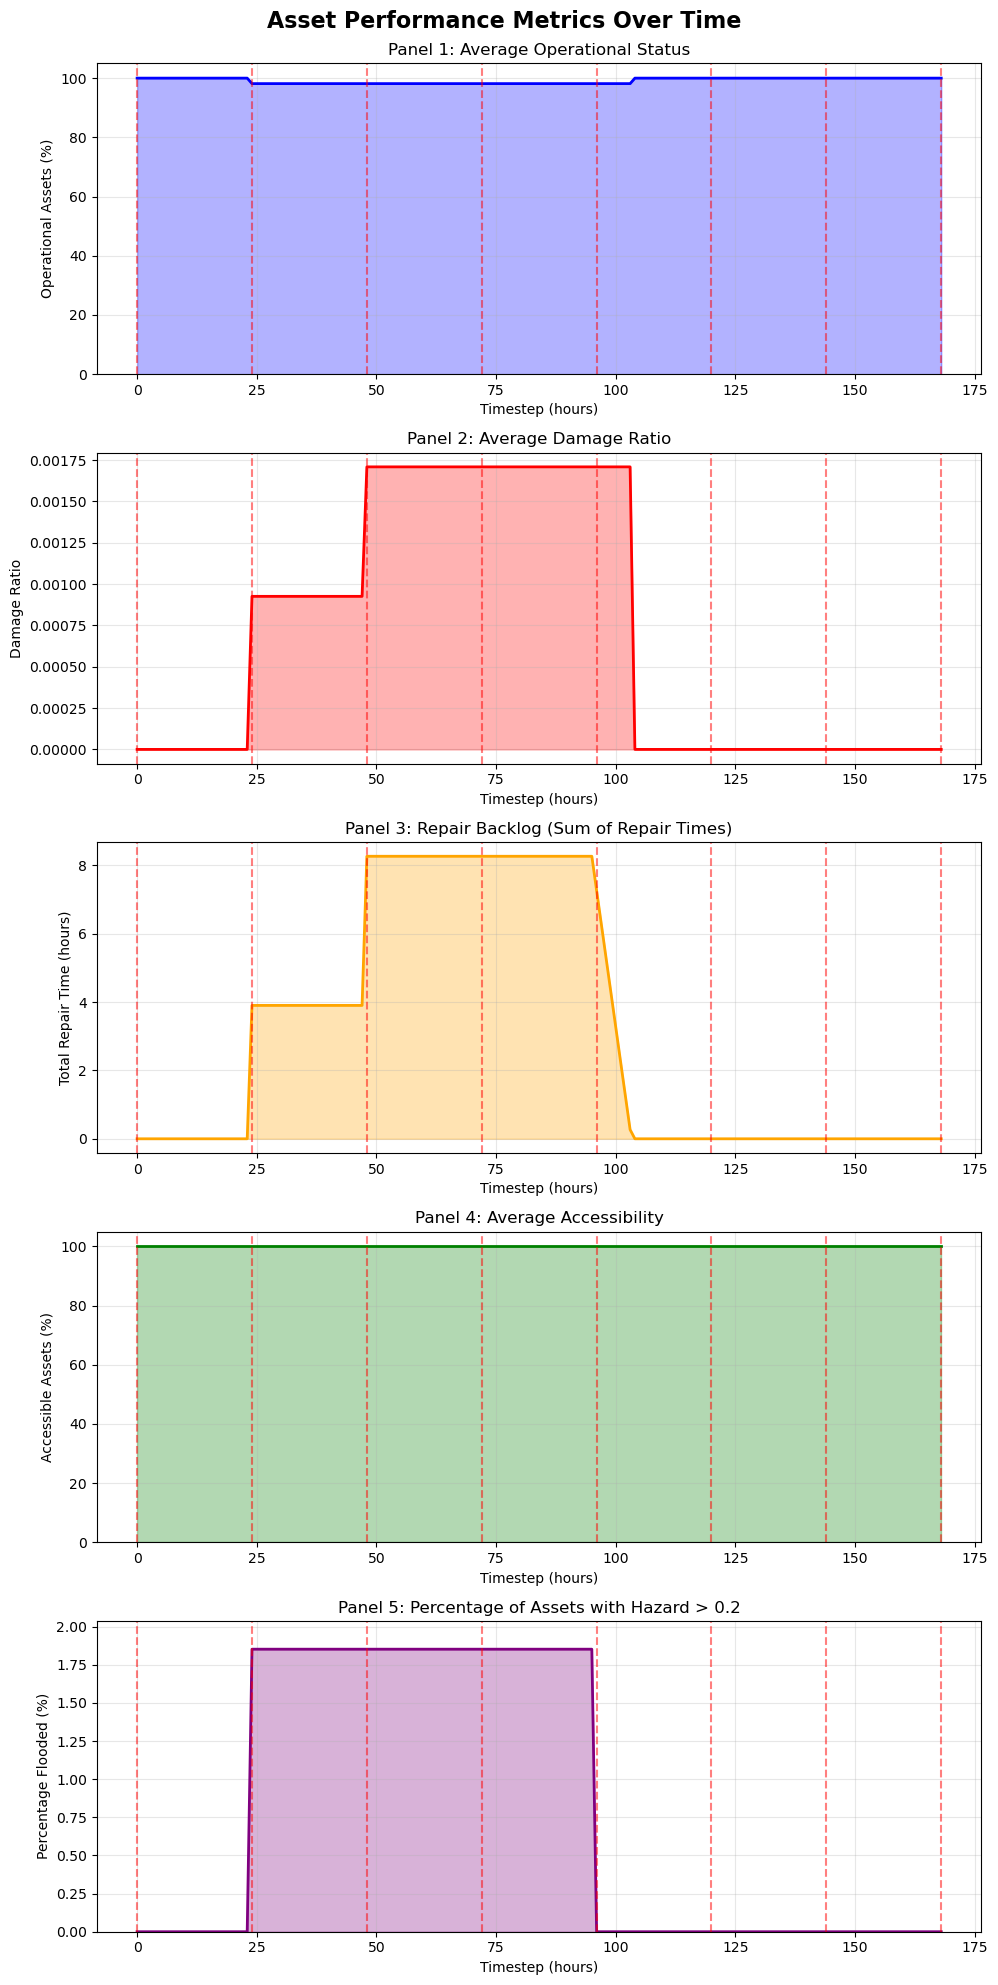

=== SUMMARY STATISTICS ===
Total timesteps analyzed: 169
Simulation duration: 168 hours (8 days)
Number of assets: 54

Final state (last timestep):
  Operational assets: 100.0%
  Average damage ratio: 0.000
  Total repair backlog: 0.0 hours
  Accessible assets: 100.0%
  Percentage flooded: 0.0%

Relevant states:
  Worst operational at timestep 24.0: 98.1%
  Maximum flooding: 1.9%
  Peak flooding occurred at timestep(s): [24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95] (absolute maximum: 1.9%)
  Top 5% flooding events (≥1.9%): 72 timesteps
  Severe flooding timesteps (showing top 10):
    Timestep 24 (Day 1, Hour 0): 1.9% flooded
    Timestep 25 (Day 1, Hour 1): 1.9% flooded
    Timestep 26 (Day 1, Hour 2): 1.9% flooded
    Timestep 27 (Day 1, Hour 3)

In [24]:
# Visualisation
df_results = gpd.GeoDataFrame(results)

if 'df_results' in locals() and 'results' in locals():
    # Prepare data
    timestep_metrics = df_results.groupby('timestep').agg({
        'operational': 'mean', # Average operational status (0-1, where 1 = 100% substations are operational)
        'damage_ratio': 'mean', # Average damage ratio across all assets. [TODO] Not sure if this is very meaningful
        'repair_time': 'sum', # Total repair backlog (sum of all repair times)
        'accessible': 'mean', # Average accessibility (0-1, where 1 = 100% accessible)
        'day': 'first' # Day counter for reference, first timestep of the day, adjust based on temporal resolution
    }).reset_index()
    
    timestep_flooding = df_results.groupby('timestep').agg({
        'hazard_value': lambda x: (x > 0.2).mean() * 100,
        'day': 'first'
    }).reset_index()
    
    # Create figure with 5 subplots in single column
    fig, axes = plt.subplots(5, 1, figsize=(10, 20))
    fig.suptitle('Asset Performance Metrics Over Time', 
                 fontsize=16, fontweight='bold', y=0.99)
    # Add spacing under the suptitle to avoid overlap with panel titles
    plt.subplots_adjust(top=0.96, bottom=0.08, hspace=1.0)
    
    # Day markers
    day_markers = timestep_metrics[timestep_metrics['timestep'] % 24 == 0]['timestep']
    
    # Panel 1: Operational Status (%)
    ax1 = axes[0]
    ax1.plot(timestep_metrics['timestep'], timestep_metrics['operational'] * 100, 
             'b-', linewidth=2, label='Operational Assets')
    ax1.fill_between(timestep_metrics['timestep'], timestep_metrics['operational'] * 100, 
                     alpha=0.3, color='blue')
    ax1.set_xlabel('Timestep (hours)')
    ax1.set_ylabel('Operational Assets (%)')
    ax1.set_title('Panel 1: Average Operational Status')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 105)
    
    for day_marker in day_markers:
        ax1.axvline(x=day_marker, color='red', linestyle='--', alpha=0.5)
    
    # Panel 2: Average Damage Ratio
    ax2 = axes[1]
    ax2.plot(timestep_metrics['timestep'], timestep_metrics['damage_ratio'], 
             'r-', linewidth=2, label='Damage Ratio')
    ax2.fill_between(timestep_metrics['timestep'], timestep_metrics['damage_ratio'], 
                     alpha=0.3, color='red')
    ax2.set_xlabel('Timestep (hours)')
    ax2.set_ylabel('Damage Ratio')
    ax2.set_title('Panel 2: Average Damage Ratio')
    ax2.grid(True, alpha=0.3)
    
    for day_marker in day_markers:
        ax2.axvline(x=day_marker, color='red', linestyle='--', alpha=0.5)
    
    # Panel 3: Repair Backlog (Total Repair Time)
    ax3 = axes[2]
    ax3.plot(timestep_metrics['timestep'], timestep_metrics['repair_time'], 
             'orange', linewidth=2, label='Repair Backlog')
    ax3.fill_between(timestep_metrics['timestep'], timestep_metrics['repair_time'], 
                     alpha=0.3, color='orange')
    ax3.set_xlabel('Timestep (hours)')
    ax3.set_ylabel('Total Repair Time (hours)')
    ax3.set_title('Panel 3: Repair Backlog (Sum of Repair Times)')
    ax3.grid(True, alpha=0.3)
    
    for day_marker in day_markers:
        ax3.axvline(x=day_marker, color='red', linestyle='--', alpha=0.5)
    
    # Panel 4: Average Accessibility
    ax4 = axes[3]
    ax4.plot(timestep_metrics['timestep'], timestep_metrics['accessible'] * 100, 
             'g-', linewidth=2, label='Accessible Assets')
    ax4.fill_between(timestep_metrics['timestep'], timestep_metrics['accessible'] * 100, 
                     alpha=0.3, color='green')
    ax4.set_xlabel('Timestep (hours)')
    ax4.set_ylabel('Accessible Assets (%)')
    ax4.set_title('Panel 4: Average Accessibility')
    ax4.grid(True, alpha=0.3)
    ax4.set_ylim(0, 105)
    
    for day_marker in day_markers:
        ax4.axvline(x=day_marker, color='red', linestyle='--', alpha=0.5)
    
    # Panel 5: Percentage Flooded
    ax5 = axes[4]
    ax5.plot(timestep_flooding['timestep'], timestep_flooding['hazard_value'], 
             'purple', linewidth=2, label='Percentage Flooded')
    ax5.fill_between(timestep_flooding['timestep'], timestep_flooding['hazard_value'], 
                     alpha=0.3, color='purple')
    ax5.set_xlabel('Timestep (hours)')
    ax5.set_ylabel('Percentage Flooded (%)')
    ax5.set_title('Panel 5: Percentage of Assets with Hazard > 0.2')
    ax5.grid(True, alpha=0.3)
    ax5.set_ylim(0, max(timestep_flooding['hazard_value']) * 1.1 if max(timestep_flooding['hazard_value']) > 0 else 5)
    
    for day_marker in day_markers:
        ax5.axvline(x=day_marker, color='red', linestyle='--', alpha=0.5)
    
    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()
    
    # Print combined summary statistics
    print("=== SUMMARY STATISTICS ===")
    print(f"Total timesteps analyzed: {len(timestep_metrics)}")
    print(f"Simulation duration: {timestep_metrics['timestep'].max()} hours ({timestep_metrics['day'].max() + 1} days)")
    print(f"Number of assets: {len(df_results['asset_id'].unique())}")
    print()
    
    # Final state summary
    final_state = timestep_metrics.iloc[-1]
    final_flooded = timestep_flooding['hazard_value'].iloc[-1]
    print("Final state (last timestep):")
    print(f"  Operational assets: {final_state['operational']*100:.1f}%")
    print(f"  Average damage ratio: {final_state['damage_ratio']:.3f}")
    print(f"  Total repair backlog: {final_state['repair_time']:.1f} hours")
    print(f"  Accessible assets: {final_state['accessible']*100:.1f}%")
    print(f"  Percentage flooded: {final_flooded:.1f}%")
    print()
    
    # Worst state summary
    worst_operational = timestep_metrics.loc[timestep_metrics['operational'].idxmin()]
    max_flooded = timestep_flooding['hazard_value'].max()
    peak_flooding_timesteps = timestep_flooding[timestep_flooding['hazard_value'] == max_flooded]['timestep'].tolist()
    
    print("Relevant states:")
    print(f"  Worst operational at timestep {worst_operational['timestep']}: {worst_operational['operational']*100:.1f}%")
    print(f"  Maximum flooding: {max_flooded:.1f}%")
    
    # Peak flooding details - focus on top 5% of flooding events
    if max_flooded > 0:
        # Calculate the 95th percentile threshold for more selective reporting
        flood_threshold_95th = timestep_flooding['hazard_value'].quantile(0.95)
        
        # Get top 5% flooding timesteps (those >= 95th percentile)
        top_flooding_events = timestep_flooding[timestep_flooding['hazard_value'] >= flood_threshold_95th]
        top_flooding_timesteps = top_flooding_events['timestep'].tolist()
        top_flooding_values = top_flooding_events['hazard_value'].tolist()
        
        print(f"  Peak flooding occurred at timestep(s): {peak_flooding_timesteps} (absolute maximum: {max_flooded:.1f}%)")
        print(f"  Top 5% flooding events (≥{flood_threshold_95th:.1f}%): {len(top_flooding_timesteps)} timesteps")
        
        # Show details for top flooding events (limit to first 10 for readability)
        display_limit = min(10, len(top_flooding_timesteps))
        if len(top_flooding_timesteps) > 0:
            print(f"  Severe flooding timesteps (showing top {display_limit}):")
            for i in range(display_limit):
                ts = top_flooding_timesteps[i]
                flood_val = top_flooding_values[i]
                day = ts // 24
                hour = ts % 24
                print(f"    Timestep {ts} (Day {day}, Hour {hour}): {flood_val:.1f}% flooded")
            
            if len(top_flooding_timesteps) > display_limit:
                print(f"    ... and {len(top_flooding_timesteps) - display_limit} more severe flooding events")
        
        # Summary statistics for severe flooding periods
        avg_severe_flooding = top_flooding_events['hazard_value'].mean()
        print(f"  Average flooding during severe events: {avg_severe_flooding:.1f}%")
    else:
        print(f"  No flooding events detected (all hazard values ≤ 0.2)")
    
else:
    print("No simulation results available for combined visualization. Please run the simulation first.")

In [53]:
# Sensitivity analysis flood threshold 0.2, 0.3, 0.4, 0.5
# Sensitivity analysis repair threshold 1.5, 1.9, 1.9891, 2.1, 2.5, 3.0
# Sensitivity analysis damage ratio coefficients (0.0468, 0.0077), (0.05, 0.01), (0.06, 0.015)
# Sensitivity analysis repair time coefficients (702.72, 3.14, 1.9891), (800, 4, 2), (900, 5, 3)

# Sensitivity analysis for flood threshold
flood_thresholds = [0.2, 0.3, 0.4, 0.5]
repair_thresholds = [1.5, 1.9, 1.9891, 2.1, 2.5, 3.0]
damage_ratio_coefficients = [(0.0468, 0.0077), (0.05, 0.01), (0.06, 0.015)]  
repair_time_coefficients = [(702.72, 3.14, 1.9891), (800, 4, 2), (900, 5, 3)]

# Function to run sensitivity analysis
def run_sensitivity_analysis(flood_thresholds, repair_thresholds, damage_ratio_coefficients, repair_time_coefficients):
    import tqdm
    #from powerpath.simulation import simulate_asset_damage_recovery

    results = []
    for flood_threshold in tqdm.tqdm(flood_thresholds, desc="Flood Thresholds"):
        # Uncomment the next line if you want to see the flood threshold being processed
        # print(f"Processing flood threshold: {flood_threshold}")
        
        # Run the simulation for each combination of parameters
        # gdf_msls_2 is assumed to be defined in the context where this function is called
        # If not, you need to define it or pass it as an argument
        #flood_thresholds:
        for repair_threshold in repair_thresholds:
            for damage_ratio_coeff in damage_ratio_coefficients:
                for repair_time_coeff in repair_time_coefficients:
                    gdf_msls_timesteps, timestep_results = simulate_asset_damage_recovery(
                        gdf_msls_2,  # GeoDataFrame with station geometries
                        hazard_path,  # Path to hazard maps
                        timesteps=np.arange(0, 7*24+1, 1),  # 24-hour timesteps for 7 days
                        verbose=False,  # Suppress progress messages
                        record_results=True,  # Record detailed results for time series analysis
                        flood_threshold=flood_threshold,
                        repair_threshold=repair_threshold,
                        damage_ratio_coefficients=damage_ratio_coeff,
                        repair_time_coefficients=repair_time_coeff
                    )
                    results.append({
                        'flood_threshold': flood_threshold,
                        'repair_threshold': repair_threshold,
                        'damage_ratio_coefficients': damage_ratio_coeff,
                        'repair_time_coefficients': repair_time_coeff,
                        'results': gdf_msls_timesteps,
                        'timestep_results': timestep_results  # Store timestep data for time series analysis
                    })
    return results

# Run the sensitivity analysis
sensitivity_results = run_sensitivity_analysis(
    flood_thresholds, 
    repair_thresholds, 
    damage_ratio_coefficients, 
    repair_time_coefficients
)

# Display summary of the results
print(f"Sensitivity analysis complete! Generated {len(sensitivity_results)} parameter combinations.")

for i, result in enumerate(sensitivity_results[:3]):  # Show first 3 for brevity
    print(f"\nResult {i+1}:")
    print(f"  Flood Threshold: {result['flood_threshold']}")
    print(f"  Repair Threshold: {result['repair_threshold']}")
    print(f"  Damage Ratio Coefficients: {result['damage_ratio_coefficients']}")
    print(f"  Repair Time Coefficients: {result['repair_time_coefficients']}")
    gdf = result['results']
    print(f"  Final operational assets: {gdf['operational'].mean()*100:.1f}%")
    print(f"  Final average damage ratio: {gdf['damage_ratio'].mean():.4f}")

print(f"\n... and {len(sensitivity_results)-3} more combinations.")


Flood Thresholds: 100%|██████████| 4/4 [00:30<00:00,  7.74s/it]

Sensitivity analysis complete! Generated 216 parameter combinations.

Result 1:
  Flood Threshold: 0.2
  Repair Threshold: 1.5
  Damage Ratio Coefficients: (0.0468, 0.0077)
  Repair Time Coefficients: (702.72, 3.14, 1.9891)
  Final operational assets: 100.0%
  Final average damage ratio: 0.0000

Result 2:
  Flood Threshold: 0.2
  Repair Threshold: 1.5
  Damage Ratio Coefficients: (0.0468, 0.0077)
  Repair Time Coefficients: (800, 4, 2)
  Final operational assets: 100.0%
  Final average damage ratio: 0.0000

Result 3:
  Flood Threshold: 0.2
  Repair Threshold: 1.5
  Damage Ratio Coefficients: (0.0468, 0.0077)
  Repair Time Coefficients: (900, 5, 3)
  Final operational assets: 100.0%
  Final average damage ratio: 0.0000

... and 213 more combinations.


Debugging timestep_results structure...

Result 0:
  Keys: dict_keys(['flood_threshold', 'repair_threshold', 'damage_ratio_coefficients', 'repair_time_coefficients', 'results', 'timestep_results'])
  timestep_results type: <class 'dict'>
  timestep_results keys: ['asset_id', 'timestep', 'day', 'damage_ratio', 'repair_time', 'accessible', 'operational', 'hazard_value']
    asset_id: type=<class 'list'>, length=30420
      Sample values: [0, 1, 2]
    timestep: type=<class 'list'>, length=30420
      Sample values: [np.int64(0), np.int64(0), np.int64(0)]
    day: type=<class 'list'>, length=30420
      Sample values: [np.int64(0), np.int64(0), np.int64(0)]
    damage_ratio: type=<class 'list'>, length=30420
      Sample values: [0.0, 0.0, 0.0]
    repair_time: type=<class 'list'>, length=30420
      Sample values: [0.0, 0.0, 0.0]
Starting sensitivity analysis plotting (Average Performance Over Time)...
sensitivity_results available: 216 results
Result 0: 99.51% avg operational, 0.000157 

C:\Users\peregrin\AppData\Local\Temp\ipykernel_21092\2183704549.py:149: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0, 1].boxplot(groups, labels=flood_thresholds, patch_artist=True)
C:\Users\peregrin\AppData\Local\Temp\ipykernel_21092\2183704549.py:203: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1, 1].boxplot(repair_groups, labels=flood_thresholds, patch_artist=True)
C:\Users\peregrin\AppData\Local\Temp\ipykernel_21092\2183704549.py:203: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1, 1].boxplot(repair_groups, labels=flood_thresholds, patch_artist=True)


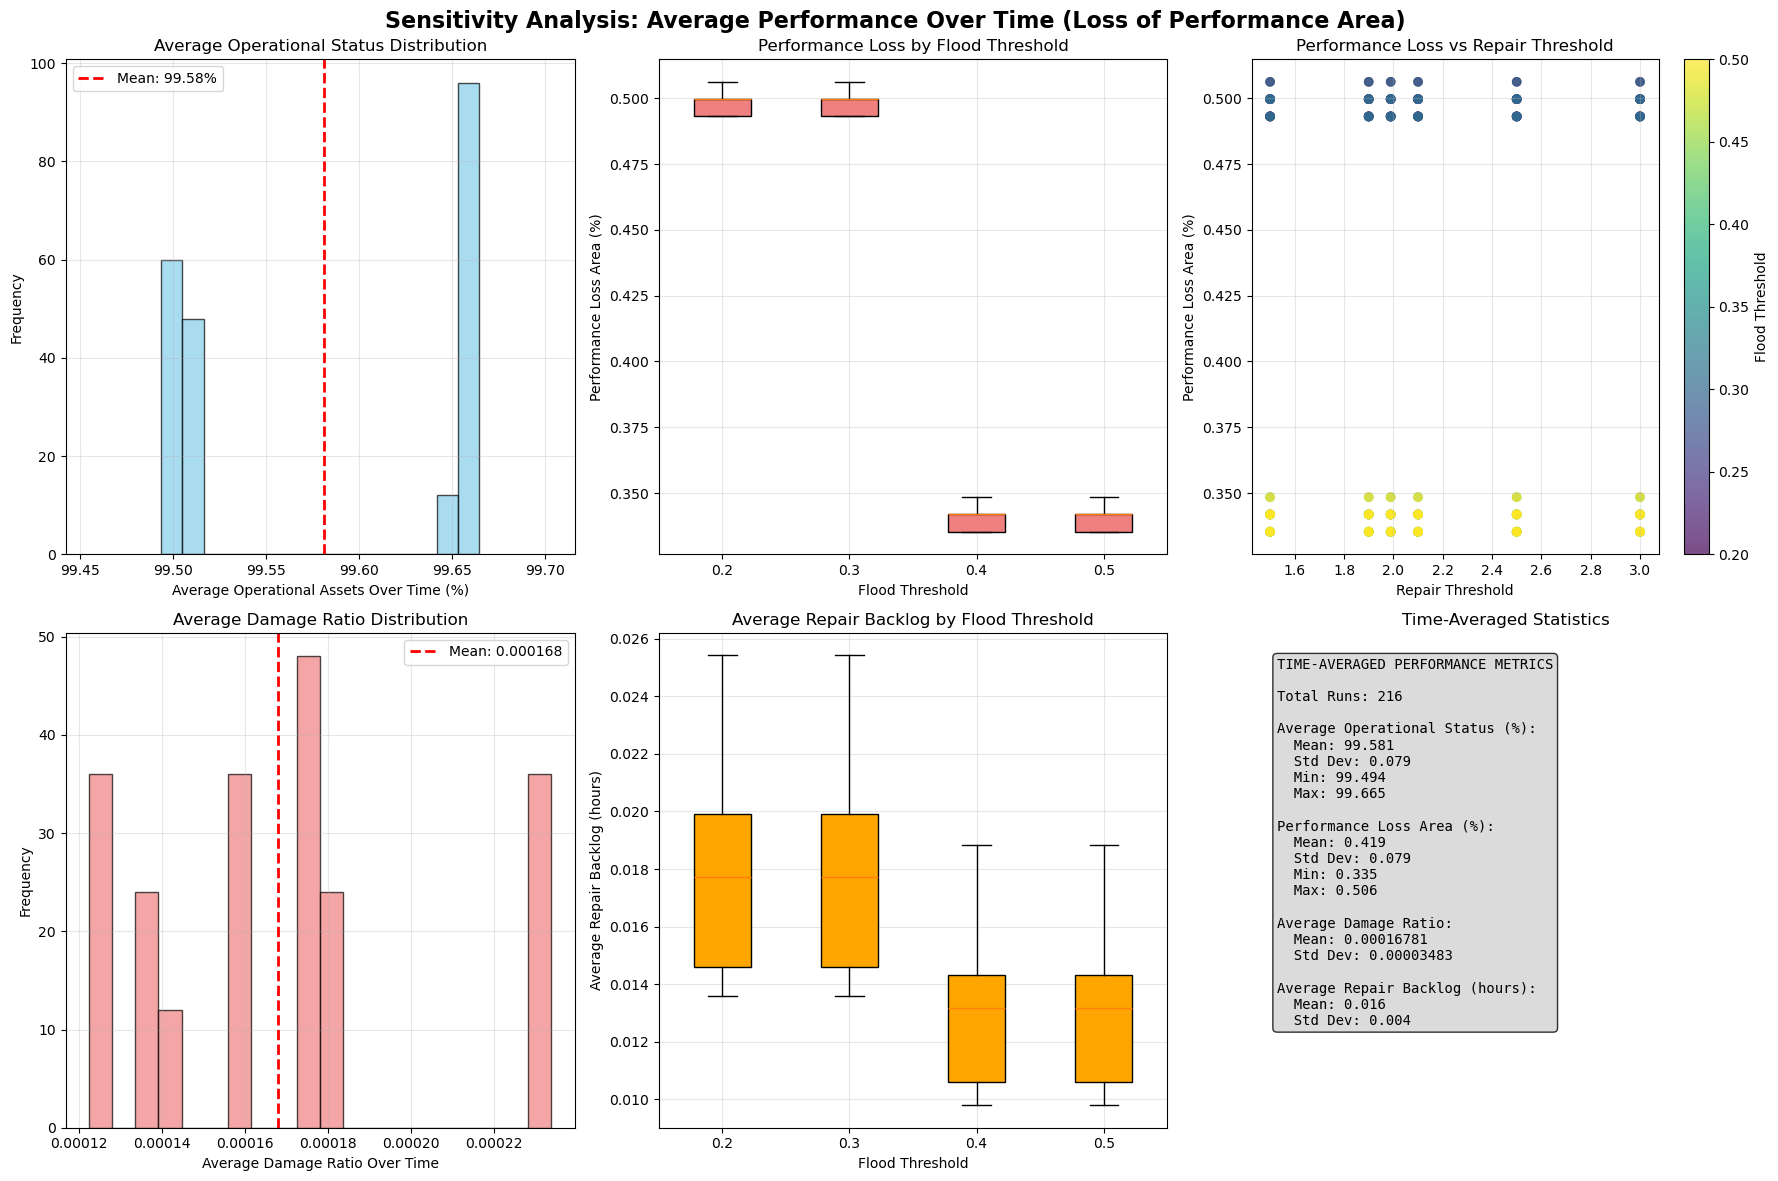


DETAILED TIME-AVERAGED SENSITIVITY ANALYSIS

Parameter Sensitivity (Time-Averaged Metrics):

=== AVG OPERATIONAL ANALYSIS ===

Effect of flood_threshold:
  flood_threshold = 0.2: mean = 99.5025, std = 0.0044
  flood_threshold = 0.3: mean = 99.5025, std = 0.0044
  flood_threshold = 0.4: mean = 99.6603, std = 0.0044
  flood_threshold = 0.5: mean = 99.6603, std = 0.0044

Effect of repair_threshold:
  repair_threshold = 1.5: mean = 99.5814, std = 0.0801
  repair_threshold = 1.9: mean = 99.5814, std = 0.0801
  repair_threshold = 1.9891: mean = 99.5814, std = 0.0801
  repair_threshold = 2.1: mean = 99.5814, std = 0.0801
  repair_threshold = 2.5: mean = 99.5814, std = 0.0801
  repair_threshold = 3.0: mean = 99.5814, std = 0.0801

=== PERFORMANCE LOSS ANALYSIS ===

Effect of flood_threshold:
  flood_threshold = 0.2: mean = 0.4975, std = 0.0044
  flood_threshold = 0.3: mean = 0.4975, std = 0.0044
  flood_threshold = 0.4: mean = 0.3397, std = 0.0044
  flood_threshold = 0.5: mean = 0.3397, std =

In [62]:
# Sensitivity Analysis Plotting - Average Performance Over Time ("Loss of Performance Area")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def calculate_performance_metrics_over_time(timestep_results):
    """
    Calculate performance metrics averaged over time (area under the curve)
    This represents the total "loss of performance" during the simulation period.
    """
    if not timestep_results:
        return None, None, None
    
    # Convert timestep results to DataFrame
    df_timesteps = pd.DataFrame(timestep_results)
    
    # Group by timestep and calculate averages
    timestep_metrics = df_timesteps.groupby('timestep').agg({
        'operational': 'mean',  # Average operational status at each timestep
        'damage_ratio': 'mean',  # Average damage ratio at each timestep
        'repair_time': 'sum'     # Total repair backlog at each timestep
    }).reset_index()
    
    # Calculate area under the curve (average over time)
    avg_operational_over_time = timestep_metrics['operational'].mean() * 100  # Convert to percentage
    avg_damage_ratio_over_time = timestep_metrics['damage_ratio'].mean()
    avg_repair_backlog_over_time = timestep_metrics['repair_time'].mean()
    
    # Calculate performance loss metrics
    perfect_performance = 100.0  # 100% operational would be perfect
    performance_loss_area = perfect_performance - avg_operational_over_time
    
    return {
        'avg_operational_over_time': avg_operational_over_time,
        'avg_damage_ratio_over_time': avg_damage_ratio_over_time, 
        'avg_repair_backlog_over_time': avg_repair_backlog_over_time,
        'performance_loss_area': performance_loss_area,
        'timestep_metrics': timestep_metrics
    }

def plot_time_averaged_sensitivity_analysis(sensitivity_results):
    """
    Plot comprehensive sensitivity analysis using time-averaged performance metrics.
    
    Parameters:
    sensitivity_results: List of dictionaries containing simulation results with timestep data
    """
    import pandas as pd
    
    print("Starting sensitivity analysis plotting (Average Performance Over Time)...")
    print(f"sensitivity_results available: {len(sensitivity_results)} results")
    
    # Extract time-averaged performance metrics from all results
    performance_loss_values = []
    operational_avg_values = []
    damage_ratio_avg_values = []
    repair_backlog_avg_values = []
    
    for i, result in enumerate(sensitivity_results):
        if i < 3:  # Print first 3 for verification
            print(f"Result {i}: ", end="")
        
        try:
            if 'timestep_results' not in result:
                if i < 3:
                    print("No timestep_results found")
                continue
                
            timestep_data = result['timestep_results']
            
            # Convert dictionary to DataFrame
            df = pd.DataFrame(timestep_data)
            
            # Calculate time-averaged metrics (aggregate by timestep first)
            timestep_summary = df.groupby('timestep').agg({
                'operational': 'mean',
                'damage_ratio': 'mean',
                'repair_time': 'mean'
            }).reset_index()
            
            avg_operational = timestep_summary['operational'].mean() * 100  # Convert to percentage
            avg_damage_ratio = timestep_summary['damage_ratio'].mean()
            avg_repair_backlog = timestep_summary['repair_time'].mean()  # Using repair_time as proxy for backlog
            
            # Performance loss area = average loss over time
            performance_loss = (100 - avg_operational)  # Percentage loss
            
            operational_avg_values.append(avg_operational)
            damage_ratio_avg_values.append(avg_damage_ratio)
            repair_backlog_avg_values.append(avg_repair_backlog)
            performance_loss_values.append(performance_loss)
            
            if i < 3:
                print(f"{avg_operational:.2f}% avg operational, {avg_damage_ratio:.6f} avg damage ratio, {performance_loss:.2f}% performance loss")
                
        except Exception as e:
            if i < 3:
                print(f"Error processing result {i}: {e}")
            continue
    
    if len(operational_avg_values) == 0:
        print("No valid data found! Check the timestep_results structure.")
        return
    
    print(f"Total values extracted: {len(operational_avg_values)}")
    print(f"Average operational range: {min(operational_avg_values):.2f}% to {max(operational_avg_values):.2f}%")
    print(f"Performance loss range: {min(performance_loss_values):.2f}% to {max(performance_loss_values):.2f}%")
    print(f"Average damage ratio range: {min(damage_ratio_avg_values):.6f} to {max(damage_ratio_avg_values):.6f}")
    
    # Duplicate the ranges for verification
    print(f"Total values extracted: {len(operational_avg_values)}")
    print(f"Average operational range: {min(operational_avg_values):.2f}% to {max(operational_avg_values):.2f}%")
    print(f"Performance loss range: {min(performance_loss_values):.2f}% to {max(performance_loss_values):.2f}%")
    print(f"Average damage ratio range: {min(damage_ratio_avg_values):.6f} to {max(damage_ratio_avg_values):.6f}")
    
    # Create comprehensive visualization for time-averaged performance
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Sensitivity Analysis: Average Performance Over Time (Loss of Performance Area)', fontsize=16, fontweight='bold')
    
    # Row 1: Performance distributions
    # Plot 1: Average Operational Status Distribution (zoomed out for better interpretability)
    axes[0, 0].hist(operational_avg_values, bins=15, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].axvline(np.mean(operational_avg_values), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(operational_avg_values):.2f}%')
    axes[0, 0].set_title('Average Operational Status Distribution')
    axes[0, 0].set_xlabel('Average Operational Assets Over Time (%)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()
    # Zoom out the x-axis for better interpretability
    x_min, x_max = min(operational_avg_values), max(operational_avg_values)
    x_range = x_max - x_min
    axes[0, 0].set_xlim(x_min - 0.3 * x_range, x_max + 0.3 * x_range)
    
    # Plot 2: Performance Loss by Flood Threshold (box plot)
    flood_thresholds = [0.2, 0.3, 0.4, 0.5]
    groups = []
    for ft in flood_thresholds:
        group_values = []
        for result in sensitivity_results:
            if result['flood_threshold'] == ft and 'timestep_results' in result:
                timestep_data = result['timestep_results']
                df = pd.DataFrame(timestep_data)
                timestep_summary = df.groupby('timestep')['operational'].mean()
                avg_operational = timestep_summary.mean() * 100
                performance_loss = 100 - avg_operational
                group_values.append(performance_loss)
        groups.append(group_values)
    
    bp1 = axes[0, 1].boxplot(groups, labels=flood_thresholds, patch_artist=True)
    for patch in bp1['boxes']:
        patch.set_facecolor('lightcoral')
    axes[0, 1].set_title('Performance Loss by Flood Threshold')
    axes[0, 1].set_xlabel('Flood Threshold')
    axes[0, 1].set_ylabel('Performance Loss Area (%)')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Performance Loss vs Repair Threshold (scatter plot)
    repair_thresholds = []
    loss_for_scatter = []
    flood_for_color = []
    
    for result in sensitivity_results:
        if 'timestep_results' in result:
            timestep_data = result['timestep_results']
            df = pd.DataFrame(timestep_data)
            timestep_summary = df.groupby('timestep')['operational'].mean()
            avg_operational = timestep_summary.mean() * 100
            performance_loss = 100 - avg_operational
            repair_thresholds.append(result['repair_threshold'])
            loss_for_scatter.append(performance_loss)
            flood_for_color.append(result['flood_threshold'])
    
    scatter1 = axes[0, 2].scatter(repair_thresholds, loss_for_scatter, c=flood_for_color, cmap='viridis', alpha=0.7)
    axes[0, 2].set_title('Performance Loss vs Repair Threshold')
    axes[0, 2].set_xlabel('Repair Threshold')
    axes[0, 2].set_ylabel('Performance Loss Area (%)')
    axes[0, 2].grid(True, alpha=0.3)
    plt.colorbar(scatter1, ax=axes[0, 2], label='Flood Threshold')
    
    # Row 2: Time-averaged Damage and Repair Analysis
    # Plot 4: Average Damage Ratio Distribution
    axes[1, 0].hist(damage_ratio_avg_values, bins=20, alpha=0.7, color='lightcoral', edgecolor='black')
    axes[1, 0].axvline(np.mean(damage_ratio_avg_values), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(damage_ratio_avg_values):.6f}')
    axes[1, 0].set_title('Average Damage Ratio Distribution')
    axes[1, 0].set_xlabel('Average Damage Ratio Over Time')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()
    
    # Plot 5: Average Repair Backlog by Flood Threshold
    repair_groups = []
    for ft in flood_thresholds:
        group_values = []
        for result in sensitivity_results:
            if result['flood_threshold'] == ft and 'timestep_results' in result:
                timestep_data = result['timestep_results']
                df = pd.DataFrame(timestep_data)
                timestep_summary = df.groupby('timestep')['repair_time'].mean()
                avg_repair_backlog = timestep_summary.mean()
                group_values.append(avg_repair_backlog)
        repair_groups.append(group_values)
    
    bp2 = axes[1, 1].boxplot(repair_groups, labels=flood_thresholds, patch_artist=True)
    for patch in bp2['boxes']:
        patch.set_facecolor('orange')
    axes[1, 1].set_title('Average Repair Backlog by Flood Threshold')
    axes[1, 1].set_xlabel('Flood Threshold')
    axes[1, 1].set_ylabel('Average Repair Backlog (hours)')
    axes[1, 1].grid(True, alpha=0.3)
    
    # Plot 6: Summary statistics table with time-averaged metrics
    axes[1, 2].axis('off')
    summary_text = f"""TIME-AVERAGED PERFORMANCE METRICS

Total Runs: {len(operational_avg_values)}

Average Operational Status (%):
  Mean: {np.mean(operational_avg_values):.3f}
  Std Dev: {np.std(operational_avg_values):.3f}
  Min: {np.min(operational_avg_values):.3f}
  Max: {np.max(operational_avg_values):.3f}

Performance Loss Area (%):
  Mean: {np.mean(performance_loss_values):.3f}
  Std Dev: {np.std(performance_loss_values):.3f}
  Min: {np.min(performance_loss_values):.3f}
  Max: {np.max(performance_loss_values):.3f}

Average Damage Ratio:
  Mean: {np.mean(damage_ratio_avg_values):.8f}
  Std Dev: {np.std(damage_ratio_avg_values):.8f}

Average Repair Backlog (hours):
  Mean: {np.mean(repair_backlog_avg_values):.3f}
  Std Dev: {np.std(repair_backlog_avg_values):.3f}"""
    
    axes[1, 2].text(0.05, 0.95, summary_text, transform=axes[1, 2].transAxes, fontsize=10, 
                    verticalalignment='top', fontfamily='monospace',
                    bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    axes[1, 2].set_title('Time-Averaged Statistics')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed analysis for time-averaged metrics
    print("\n" + "="*60)
    print("DETAILED TIME-AVERAGED SENSITIVITY ANALYSIS")
    print("="*60)
    
    # Create DataFrame for analysis
    analysis_data = []
    for result in sensitivity_results:
        if 'timestep_results' in result:
            timestep_data = result['timestep_results']
            df = pd.DataFrame(timestep_data)
            timestep_summary = df.groupby('timestep').agg({
                'operational': 'mean',
                'damage_ratio': 'mean',
                'repair_time': 'mean'
            })
            
            avg_operational = timestep_summary['operational'].mean() * 100
            performance_loss = 100 - avg_operational
            
            analysis_data.append({
                'flood_threshold': result['flood_threshold'],
                'repair_threshold': result['repair_threshold'],
                'avg_operational': avg_operational,
                'performance_loss': performance_loss,
                'avg_damage_ratio': timestep_summary['damage_ratio'].mean(),
                'avg_repair_backlog': timestep_summary['repair_time'].mean()
            })
    
    # Parameter sensitivity analysis for time-averaged metrics
    print(f"\nParameter Sensitivity (Time-Averaged Metrics):")
    
    for metric in ['avg_operational', 'performance_loss', 'avg_damage_ratio', 'avg_repair_backlog']:
        print(f"\n=== {metric.upper().replace('_', ' ')} ANALYSIS ===")
        
        param_df = pd.DataFrame(analysis_data)
        
        for param in ['flood_threshold', 'repair_threshold']:
            print(f"\nEffect of {param}:")
            grouped = param_df.groupby(param)[metric].agg(['mean', 'std']).reset_index()
            
            for _, row in grouped.iterrows():
                print(f"  {param} = {row[param]}: mean = {row['mean']:.4f}, std = {row['std']:.4f}")
    
    # Find best and worst performers (time-averaged)
    df_analysis = pd.DataFrame(analysis_data)
    
    best_result = df_analysis.loc[df_analysis['avg_operational'].idxmax()]
    worst_result = df_analysis.loc[df_analysis['avg_operational'].idxmin()]
    
    print(f"\n" + "="*50)
    print("BEST PERFORMING CONFIGURATION (Time-Averaged):")
    print(f"  Flood threshold: {best_result['flood_threshold']}")
    print(f"  Repair threshold: {best_result['repair_threshold']}")
    print(f"  Average operational: {best_result['avg_operational']:.2f}%")
    print(f"  Performance loss: {best_result['performance_loss']:.2f}%")
    
    print(f"\nWORST PERFORMING CONFIGURATION (Time-Averaged):")
    print(f"  Flood threshold: {worst_result['flood_threshold']}")
    print(f"  Repair threshold: {worst_result['repair_threshold']}")
    print(f"  Average operational: {worst_result['avg_operational']:.2f}%")
    print(f"  Performance loss: {worst_result['performance_loss']:.2f}%")
    
    print(f"\nTime-averaged sensitivity analysis completed successfully!")
    print(f"Performance Loss Area represents the average deviation from 100% operational status over the entire simulation period.")
    print(f"This captures the cumulative impact of flooding events and recovery under different disruption/repair assumptions.")

# Debug: Check the structure of timestep_results
if 'sensitivity_results' in locals() and sensitivity_results:
    print("Debugging timestep_results structure...")
    
    for i, result in enumerate(sensitivity_results[:1]):  # Check first result
        print(f"\nResult {i}:")
        print(f"  Keys: {result.keys()}")
        
        if 'timestep_results' in result:
            timestep_data = result['timestep_results']
            print(f"  timestep_results type: {type(timestep_data)}")
            
            if isinstance(timestep_data, dict):
                print(f"  timestep_results keys: {list(timestep_data.keys())}")
                
                # Check each key's structure
                for key in list(timestep_data.keys())[:5]:  # First 5 keys
                    value = timestep_data[key]
                    print(f"    {key}: type={type(value)}, length={len(value) if hasattr(value, '__len__') else 'N/A'}")
                    if hasattr(value, '__len__') and len(value) > 0:
                        print(f"      Sample values: {value[:3] if isinstance(value, list) else 'N/A'}")
            else:
                print(f"  timestep_results content: {timestep_data}")
        else:
            print("  No timestep_results found")
else:
    print("sensitivity_results not found")

# Run the plotting function if sensitivity_results is available
if 'sensitivity_results' in locals() and sensitivity_results:
    plot_time_averaged_sensitivity_analysis(sensitivity_results)
else:
    print("sensitivity_results not found. Please run the sensitivity analysis first.")

# Hoogspanning heeft geen exposure

# Laagspanning

In [25]:
gdf_ls_2 = gpd.GeoDataFrame()
gdf_ls_2['geometry'] = gdf_ls.geometry
# gdf_ls_2

C:\Users\peregrin\AppData\Local\Temp\ipykernel_21092\4063060600.py:2: FutureWarning: You are adding a column named 'geometry' to a GeoDataFrame constructed without an active geometry column. Currently, this automatically sets the active geometry column to 'geometry' but in the future that will no longer happen. Instead, either provide geometry to the GeoDataFrame constructor (GeoDataFrame(... geometry=GeoSeries()) or use `set_geometry('geometry')` to explicitly set the active geometry column.
  gdf_ls_2['geometry'] = gdf_ls.geometry


In [26]:
# Read the raster file
with rasterio.open(hazard_map) as src:
    # Read the TIF file as a numpy array
    tif_array = src.read(1)  # Change the band index (1) if necessary

    # Get the CRS from the rasterio object
    raster_crs = src.crs

    points = gdf_ls_2

    # Ensure CRS match
    points = points.to_crs(raster_crs)
    points2 = gpd.clip(points, buffer_polygon_network)

    # Filter points that fall within the raster bounds
    points2 = points2[points2.geometry.apply(lambda point: 0 <= src.index(point.x, point.y)[0] < src.height and 0 <= src.index(point.x, point.y)[1] < src.width)]

    # Add a new column to store hazard values
    points2['hazard_value'] = points2.geometry.apply(lambda point: get_raster_value(src, point))



In [27]:
points_with_hazard = points2[points2['hazard_value'] > 0.2]
if points_with_hazard.empty:
    print("No points with hazard values greater than 0.2 found.")
else:
    points_with_hazard.explore(column='hazard_value', cmap='viridis_r', tiles='CartoDB positron',marker_kwds={'radius': 6})

No points with hazard values greater than 0.2 found.


In [28]:
result = assign_hazard_to_voronoi(points_with_hazard, voronoi_gdf_ls)
result_with_hazard = result[result['hazard_value']>0.2]
if result_with_hazard.empty:
    print("No Voronoi polygons with hazard values greater than 0.2 found.")
else:
    result_with_hazard.explore(column='hazard_value',cmap='viridis_r', tiles='CartoDB positron')


No Voronoi polygons with hazard values greater than 0.2 found.


C:\Users\peregrin\AppData\Local\Temp\ipykernel_21092\3216551156.py:46: FutureWarning: <class 'geopandas.array.GeometryArray'>._reduce will require a `keepdims` parameter in the future
  points_with_hazard = points_with_hazard.dropna(subset=['geometry', 'hazard_value'])
